In [1]:
import numpy as np
import pandas as pd

In [2]:
import os
df = pd.read_csv('tweets_v8.csv' if os.path.exists('tweets_v8.csv') else '/content/tweets_v8.csv' if os.path.exists('/content/tweets_v8.csv') else 'data/external/tweets_v8.csv' if os.path.exists('data/external/tweets_v8.csv') else '../data/external/tweets_v8.csv')
# Tweets have no ground-truth sentiment labels: 'text' is the raw tweet column.
# Rename to 'clean_comment' so the downstream experiment code stays unchanged.
df = df.rename(columns={'text': 'clean_comment'})
if 'is_retweet' in df.columns:
    df = df[~df['is_retweet'].astype(bool)]  # drop retweets

In [3]:
# Pseudo-label tweets with VADER (the dataset has no ground-truth sentiment labels)
import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
df['sentiment_polarity'] = df['clean_comment'].apply(lambda t: sia.polarity_scores(str(t))['compound'])
df['category'] = df['sentiment_polarity'].apply(lambda s: 1 if s >= 0.05 else (-1 if s <= -0.05 else 0))
df['category'].value_counts()

category
 1    33033
 0    31380
-1    15606
Name: count, dtype: int64

In [4]:
df.shape

(80019, 14)

In [5]:
df.sample()['clean_comment'].values

array(['It’s a @GenzeeNFTS Halloween!! Look who joined the party 👀🚷💥💀🧟\u200d♂️👻🦑 #SquidGame https://t.co/773aJlM7oi'],
      dtype=object)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80019 entries, 0 to 80018
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_name           80015 non-null  object 
 1   user_location       56149 non-null  object 
 2   user_description    74808 non-null  object 
 3   user_created        80019 non-null  object 
 4   user_followers      80019 non-null  int64  
 5   user_friends        80019 non-null  int64  
 6   user_favourites     80019 non-null  int64  
 7   user_verified       80019 non-null  bool   
 8   date                80019 non-null  object 
 9   clean_comment       80019 non-null  object 
 10  source              80019 non-null  object 
 11  is_retweet          80019 non-null  bool   
 12  sentiment_polarity  80019 non-null  float64
 13  category            80019 non-null  int64  
dtypes: bool(2), float64(1), int64(4), object(7)
memory usage: 7.5+ MB


In [7]:
df.isnull().sum()

user_name                 4
user_location         23870
user_description       5211
user_created              0
user_followers            0
user_friends              0
user_favourites           0
user_verified             0
date                      0
clean_comment             0
source                    0
is_retweet                0
sentiment_polarity        0
category                  0
dtype: int64

In [8]:
df[df['clean_comment'].isna()]

,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,clean_comment,source,is_retweet,sentiment_polarity,category


In [9]:
df[df['clean_comment'].isna()]['category'].value_counts()

Series([], Name: count, dtype: int64)

In [10]:
df.dropna(inplace=True)

In [11]:
df.duplicated().sum()

231

In [12]:
df[df.duplicated()]

,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,clean_comment,source,is_retweet,sentiment_polarity,category
65492,Tony Mitsinga,London,"Here's where i speak my mind:\n\nFilm Maker, D...",2011-07-20 22:12:35+00:00,324,1384,3078,False,2021-10-19 10:50:22+00:00,I've yet to see a theory that the reason #Squi...,Twitter for Android,False,0.5598,1
65510,Series Boutique,ישראל,"Series are our passion, we lose to create desi...",2021-10-19 10:36:27+00:00,0,0,0,False,2021-10-19 10:45:05+00:00,#SquidGame #tshirtdesign have arrived in our #...,Twitter for iPhone,False,0.0000,0
65585,𝕋𝕙𝕖 𝔾𝕚𝕒𝕟𝕥,"Liverpool, England",Aaaaaargh that’s heavy custard that lad,2011-04-26 14:16:19+00:00,526,593,1808,False,2021-10-19 10:24:21+00:00,Not very good that #SquidGame is it?!,Twitter for iPhone,False,-0.4432,-1
65605,Yash tripathi,"Nagpur, India","Must we dream our dreams and have them,too?",2021-06-21 09:30:33+00:00,5,22,286,False,2021-10-19 10:18:20+00:00,Your mama so fat that even when she steps on t...,Twitter Web App,False,0.0000,0
65607,I.T.S.,"Newbury, Berkshire",A braver flavour. Experts in natural flavourings.,2013-10-08 12:47:33+00:00,370,979,894,False,2021-10-19 10:17:57+00:00,"So then, who's been watching #SquidGame on #Ne...",Twitter Web App,False,0.2500,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69902,Michael Ellis,"Liverpool, England",Personal Trainer / Online Coach / Attempts Hum...,2014-12-21 23:42:35+00:00,158,323,598,False,2021-10-18 10:28:15+00:00,Why ‘knowing what to do’ is not enough…\n\nhtt...,Twitter for iPhone,False,0.0000,0
69917,Jayam Publicity,Pondicherry,OOHSolutions | Space Advocacy | Market entry |...,2019-10-04 12:28:10+00:00,5,80,7,False,2021-10-18 10:25:39+00:00,continue in the comments 😄\n.\n.\n.\n#squidgam...,Twitter Web App,False,0.0000,0
69923,Nasi Kukus Tonggek,"Batu Pahat, Johor, Malaysia.",A lazy animator in training. \nI usually uploa...,2021-05-27 04:49:38+00:00,619,117,1329,False,2021-10-18 10:24:31+00:00,@KotteAnimation beat me to it first. 😂\n\nHere...,Twitter Web App,False,0.0000,0
69961,MarieLouiseGumuchian,London,Journalist based in London. Previously reporti...,2011-04-26 22:14:26+00:00,1648,178,17,False,2021-10-18 10:16:04+00:00,"Red light, green cash: Squid Game helps revive...",Twitter Web App,False,0.6124,1


In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

0

In [15]:
df[(df['clean_comment'].str.strip() == '')]

,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,clean_comment,source,is_retweet,sentiment_polarity,category


In [16]:
df = df[~(df['clean_comment'].str.strip() == '')]

In [17]:
# Convert the 'clean_comment' column to lowercase
df['clean_comment'] = df['clean_comment'].str.lower()

# Verify the transformation by displaying the first few rows
df.head()


,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,clean_comment,source,is_retweet,sentiment_polarity,category
3,YoMo.Mdp,Any pronouns,Where the heck is the karma\nI'm going on my s...,2021-02-14 13:21:22+00:00,3,277,1341,False,2021-10-06 12:05:04+00:00,//blood on 1st slide\ni'm joining the squidgam...,Twitter Web App,False,-0.6486,-1
4,Laura Reactions,France,I talk and I make reactions videos about shows...,2018-12-19 20:38:28+00:00,330,152,2278,False,2021-10-06 12:05:00+00:00,"the two first games, players were killed by th...",Twitter Web App,False,-0.9169,-1
5,Peyman 🅚🅐🅘,United Kingdom,Official @KardiaChain $KAI Ambassador\nMarketi...,2018-01-27 12:07:31+00:00,546,318,6265,False,2021-10-06 12:04:54+00:00,$thg\ngoing to explode to 4b marketcap very so...,Twitter for Android,False,0.0000,0
7,BarBiE Fábregas 🇿🇦,South Africa,Legal Administrator👩🏾‍💻|Soccer Fanatic⚽️ #Dail...,2011-03-28 18:56:28+00:00,1877,2057,33186,False,2021-10-06 12:04:26+00:00,please vote in my daily poll. \nthanks. 😊\n\nd...,Twitter for iPhone,False,0.8708,1
9,Kevin Franco,"Calgary, Canada",When it comes to describing myself in a one li...,2009-05-11 20:14:51+00:00,1027,278,20902,False,2021-10-06 12:04:10+00:00,i discovered english audio after 5 episodes of...,Twitter Web App,False,0.0000,0


In [18]:
df[df['clean_comment'].apply(lambda x: x.endswith(' ') or x.startswith(' '))]

,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,clean_comment,source,is_retweet,sentiment_polarity,category


In [19]:
# Remove trailing and leading whitespaces from the 'clean_comment' column
df['clean_comment'] = df['clean_comment'].str.strip()

# Verify the transformation by checking for any remaining trailing whitespaces
df['clean_comment'].apply(lambda x: x.endswith(' ') or x.startswith(' ')).sum()

0

In [20]:
# Identify comments containing URLs
url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
comments_with_urls = df[df['clean_comment'].str.contains(url_pattern, regex=True)]

# Display the comments containing URLs
comments_with_urls.head()


,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,clean_comment,source,is_retweet,sentiment_polarity,category
3,YoMo.Mdp,Any pronouns,Where the heck is the karma\nI'm going on my s...,2021-02-14 13:21:22+00:00,3,277,1341,False,2021-10-06 12:05:04+00:00,//blood on 1st slide\ni'm joining the squidgam...,Twitter Web App,False,-0.6486,-1
4,Laura Reactions,France,I talk and I make reactions videos about shows...,2018-12-19 20:38:28+00:00,330,152,2278,False,2021-10-06 12:05:00+00:00,"the two first games, players were killed by th...",Twitter Web App,False,-0.9169,-1
5,Peyman 🅚🅐🅘,United Kingdom,Official @KardiaChain $KAI Ambassador\nMarketi...,2018-01-27 12:07:31+00:00,546,318,6265,False,2021-10-06 12:04:54+00:00,$thg\ngoing to explode to 4b marketcap very so...,Twitter for Android,False,0.0000,0
7,BarBiE Fábregas 🇿🇦,South Africa,Legal Administrator👩🏾‍💻|Soccer Fanatic⚽️ #Dail...,2011-03-28 18:56:28+00:00,1877,2057,33186,False,2021-10-06 12:04:26+00:00,please vote in my daily poll. \nthanks. 😊\n\nd...,Twitter for iPhone,False,0.8708,1
9,Kevin Franco,"Calgary, Canada",When it comes to describing myself in a one li...,2009-05-11 20:14:51+00:00,1027,278,20902,False,2021-10-06 12:04:10+00:00,i discovered english audio after 5 episodes of...,Twitter Web App,False,0.0000,0


In [21]:
# Identify comments containing new line characters
comments_with_newline = df[df['clean_comment'].str.contains('\n')]

# Display the comments containing new line characters
comments_with_newline.head()


,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,clean_comment,source,is_retweet,sentiment_polarity,category
3,YoMo.Mdp,Any pronouns,Where the heck is the karma\nI'm going on my s...,2021-02-14 13:21:22+00:00,3,277,1341,False,2021-10-06 12:05:04+00:00,//blood on 1st slide\ni'm joining the squidgam...,Twitter Web App,False,-0.6486,-1
5,Peyman 🅚🅐🅘,United Kingdom,Official @KardiaChain $KAI Ambassador\nMarketi...,2018-01-27 12:07:31+00:00,546,318,6265,False,2021-10-06 12:04:54+00:00,$thg\ngoing to explode to 4b marketcap very so...,Twitter for Android,False,0.0000,0
7,BarBiE Fábregas 🇿🇦,South Africa,Legal Administrator👩🏾‍💻|Soccer Fanatic⚽️ #Dail...,2011-03-28 18:56:28+00:00,1877,2057,33186,False,2021-10-06 12:04:26+00:00,please vote in my daily poll. \nthanks. 😊\n\nd...,Twitter for iPhone,False,0.8708,1
11,soph 🍁,arlor • ddgc,18 they/them/他 chinese lesbian | #1 figayda st...,2016-12-17 03:49:20+00:00,371,368,6415,False,2021-10-06 12:03:34+00:00,— squid game (2021): deaths and foreshadowing ...,Twitter for iPhone,False,0.0000,0
14,Yemzxy,"Lagos, Nigeria",Am special because am a triplet,2021-06-11 16:47:29+00:00,39,160,12,False,2021-10-06 12:02:57+00:00,the saga continues \nget data cheap @honourwo...,Twitter for Android,False,0.0000,0


In [22]:
# Remove new line characters from the 'clean_comment' column
df['clean_comment'] = df['clean_comment'].str.replace('\n', ' ', regex=True)

# Verify the transformation by checking for any remaining new lines
comments_with_newline_remaining = df[df['clean_comment'].str.contains('\n')]
comments_with_newline_remaining


,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,clean_comment,source,is_retweet,sentiment_polarity,category


## EDA

<Axes: xlabel='category', ylabel='count'>

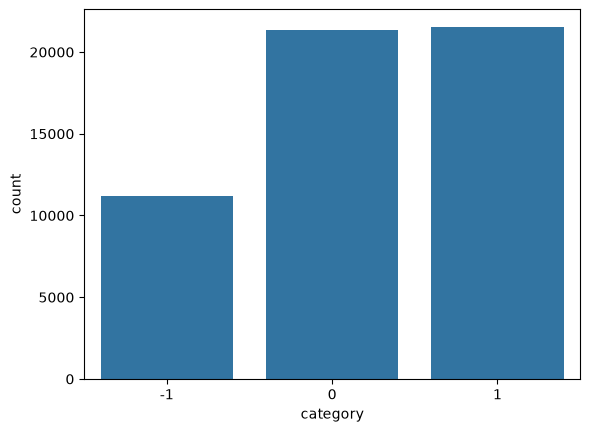

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
# distribution of classes

sns.countplot(data=df,x="category")

In [24]:
# frequency distribution of sentiments

df['category'].value_counts(normalize=True).mul(100).round(2)

category
 1    39.85
 0    39.46
-1    20.68
Name: proportion, dtype: float64

In [25]:
df['word_count'] = df['clean_comment'].apply(lambda x: len(x.split()))

In [26]:
df.sample(5)

,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,clean_comment,source,is_retweet,sentiment_polarity,category,word_count
76184,Tom Massey,"Sydney, Australia",Actor / Director / Stage Manager,2009-10-31 13:23:56+00:00,268,1194,11574,False,2021-10-30 01:35:05+00:00,so this dude said i could make some money play...,Twitter for Android,False,0.2023,1,17
29630,Aisling Schmidt,Ireland,Irish 🇮🇪 1988 👩🏻 I love traveling and cryptocu...,2010-01-21 19:57:38+00:00,17,250,441,False,2021-10-10 03:05:20+00:00,@antonsoeharyo @shibtoken @shibaarmyid i am no...,jdbNumLock,False,-0.3867,-1,11
40020,Bhuvan Krishna,"Bengaluru, India",Hey! How you doin !?,2020-09-16 05:50:11+00:00,1,31,2,False,2021-10-16 11:08:54+00:00,seong gi hun got a flight and there isn’t gonn...,Twitter for iPhone,False,0.0000,0,18
12059,₍₍...️₎₎ ꒰ ❛ ELI ❜ ꒱,🇵🇭/ eng | he/him/xe,‘ 당신은 나의 가장 큰 범죄였습니다 ‘ —— i make threads | min...,2021-08-05 13:59:22+00:00,79,54,34,False,2021-10-07 04:25:24+00:00,he’ll join the squid game while trying to disc...,Twitter for iPhone,False,0.2960,1,18
31016,Jack Andrews,"Liverpool, England",COYB,2017-08-12 09:25:57+00:00,211,894,8045,False,2021-10-14 00:31:52+00:00,i'm ready 👀 #squidgame https://t.co/nwqx4usrao,Twitter for Android,False,0.3612,1,5


In [27]:
df['word_count'].describe()

count    54036.000000
mean        14.490802
std          5.930432
min          1.000000
25%         10.000000
50%         14.000000
75%         20.000000
max         50.000000
Name: word_count, dtype: float64

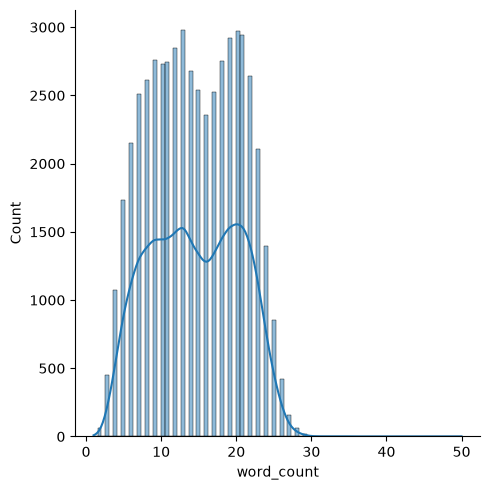

In [28]:
sns.displot(df['word_count'], kde=True)

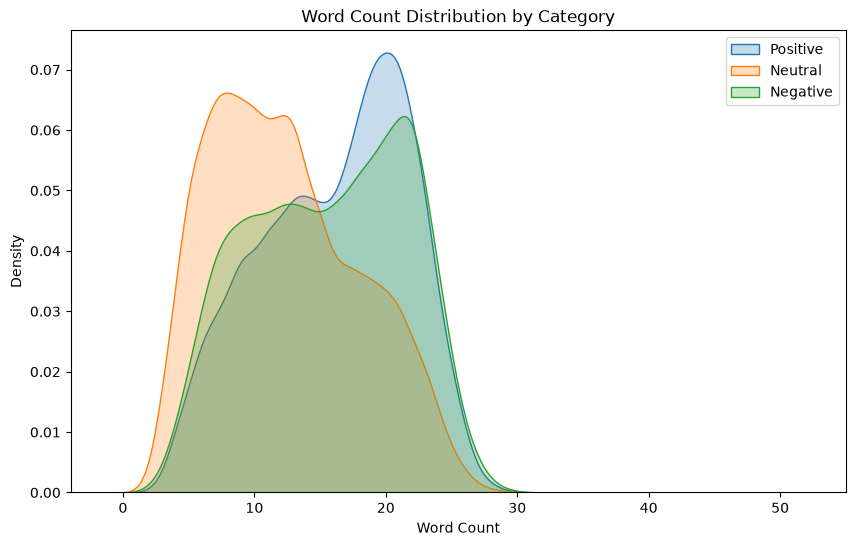

In [29]:
# Create the figure and axes
plt.figure(figsize=(10, 6))

# Plot KDE for category 1
sns.kdeplot(df[df['category'] == 1]['word_count'], label='Positive', fill=True)

# Plot KDE for category 0
sns.kdeplot(df[df['category'] == 0]['word_count'], label='Neutral', fill=True)

# Plot KDE for category -1
sns.kdeplot(df[df['category'] == -1]['word_count'], label='Negative', fill=True)

# Add title and labels
plt.title('Word Count Distribution by Category')
plt.xlabel('Word Count')
plt.ylabel('Density')

# Add a legend
plt.legend()

# Show the plot
plt.show()

**Positive comments (category 1)**: These tend to have a wider spread in word count, indicating that longer comments are more common in positive sentiments.<br>
**Neutral comments (category 0)**: The distribution shows a relatively lower frequency and is more concentrated around shorter comments compared to positive or negative ones.<br>
**Negative comments (category -1)**: These comments have a distribution somewhat similar to positive comments but with a smaller proportion of longer comments.

<Axes: ylabel='word_count'>

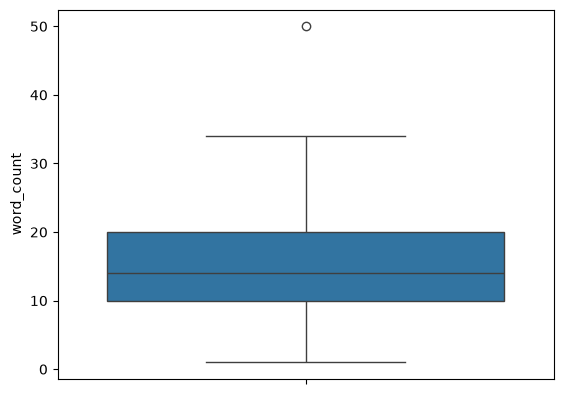

In [30]:
sns.boxplot(df['word_count'])

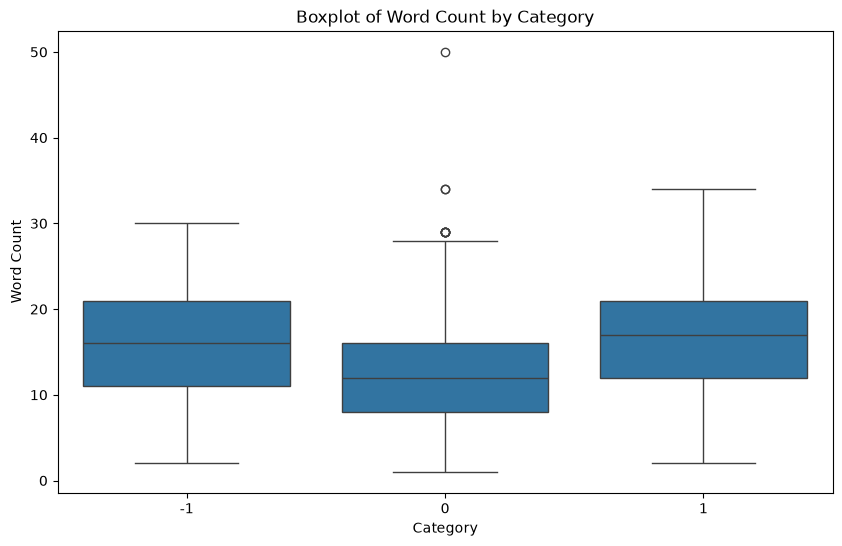

In [31]:
# Create a boxplot for the 'wordcount' column categorized by 'category'
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='category', y='word_count')
plt.title('Boxplot of Word Count by Category')
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.show()

**Positive comments (category 1)**: The median word count is relatively high, and there are several outliers with longer comments, indicating that positive comments tend to be more verbose.<br>
**Neutral comments (category 0)**: The median word count is the lowest, with a tighter interquartile range (IQR), suggesting that neutral comments are generally shorter.<br>
**Negative comments (category -1)**: The word count distribution is similar to positive comments but with a slightly lower median and fewer extreme outliers.

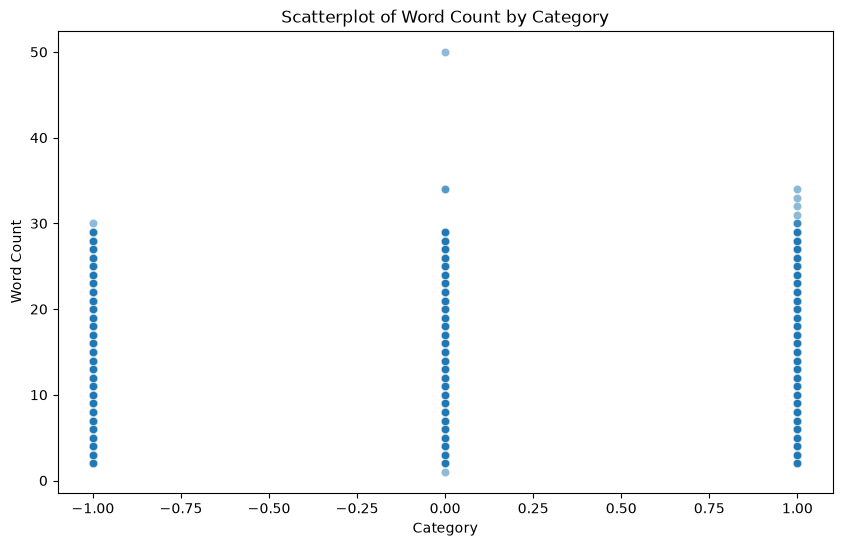

In [32]:
# Create a scatterplot between 'category' and 'wordcount'
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='category', y='word_count', alpha=0.5)
plt.title('Scatterplot of Word Count by Category')
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.show()

<Axes: xlabel='category', ylabel='word_count'>

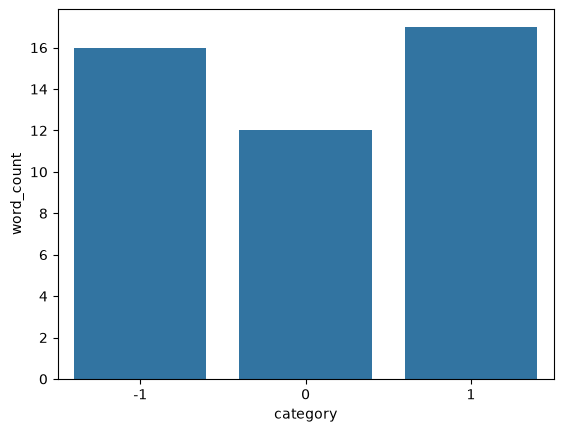

In [33]:
# median word counts among sentiments

sns.barplot(df,x='category',y='word_count',estimator='median')

In [34]:
!pip install nltk


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
from nltk.corpus import stopwords

# Download NLTK stopwords if not already downloaded
import nltk
nltk.download('stopwords')

# Define the list of English stopwords
stop_words = set(stopwords.words('english'))

# Create a new column 'num_stop_words' by counting the number of stopwords in each comment
df['num_stop_words'] = df['clean_comment'].apply(lambda x: len([word for word in x.split() if word in stop_words]))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HAI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [36]:
df.sample(5)

,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,clean_comment,source,is_retweet,sentiment_polarity,category,word_count,num_stop_words
13199,Kreon,"Florida, USA",Pokémon catcher. MMA nerd. Instagram @_kreon_ ...,2016-06-12 21:22:30+00:00,411,565,1813,False,2021-10-07 01:55:07+00:00,so i caved and finally started watching #squid...,Twitter for iPhone,False,0.0000,0,8,3
28397,Ivan Denata,Bolongan Biola,Happy potato. \nCheck my Instagram\nArtwork: @...,2009-10-06 09:54:35+00:00,630,431,5013,False,2021-10-10 09:19:05+00:00,my favorite scene ever in squid game 😢 #squidg...,Twitter for iPad,False,0.4588,1,11,2
4108,Tony DelaRosa 🇵🇭 (he/siya),"Miami, FL","ABAR Educator, DEI Strategist, Writer, Speaker...",2009-09-22 08:10:16+00:00,506,1051,1957,False,2021-10-06 00:36:53+00:00,"observed a classroom today, and a kid called m...",Twitter for iPhone,False,0.0000,0,24,10
67142,Dani-Elle Dubé,"Ottawa, Ontario",Weekend Editor @OttawaMatters/@1310News. Award...,2009-04-09 21:33:38+00:00,1826,2928,4281,True,2021-10-18 22:42:46+00:00,“wait — i remember my name now.” 😭 💔 #squidgame,Twitter for iPhone,False,0.0000,0,10,2
69320,"TOXIC, BOUJEE, AND ROWDY 😈",WORLDWIDE,There is only one thing in the world worse tha...,2020-11-03 19:42:47+00:00,421,3340,40009,False,2021-10-18 12:42:18+00:00,@urstrulyaayan amazing #squidgame,Twitter for iPhone,False,0.5859,1,3,0


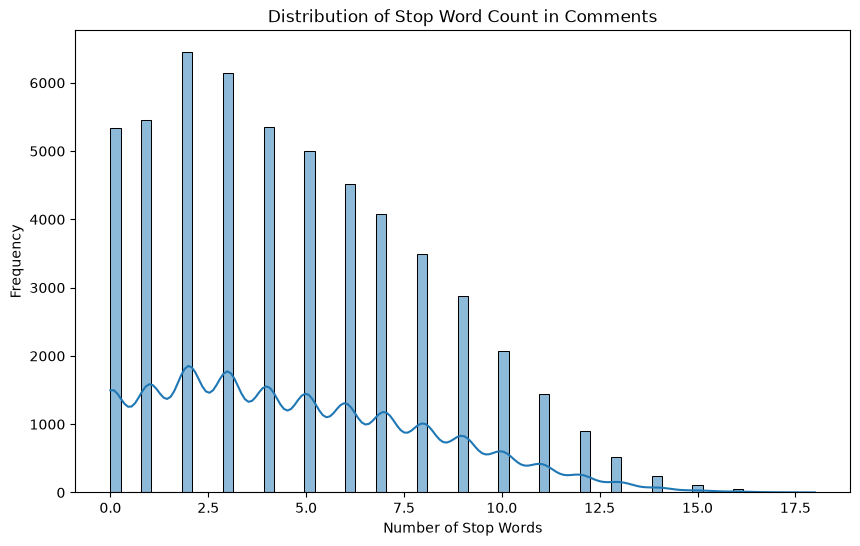

In [37]:
# Create a distribution plot (displot) for the 'num_stop_words' column
plt.figure(figsize=(10, 6))
sns.histplot(df['num_stop_words'], kde=True)
plt.title('Distribution of Stop Word Count in Comments')
plt.xlabel('Number of Stop Words')
plt.ylabel('Frequency')
plt.show()


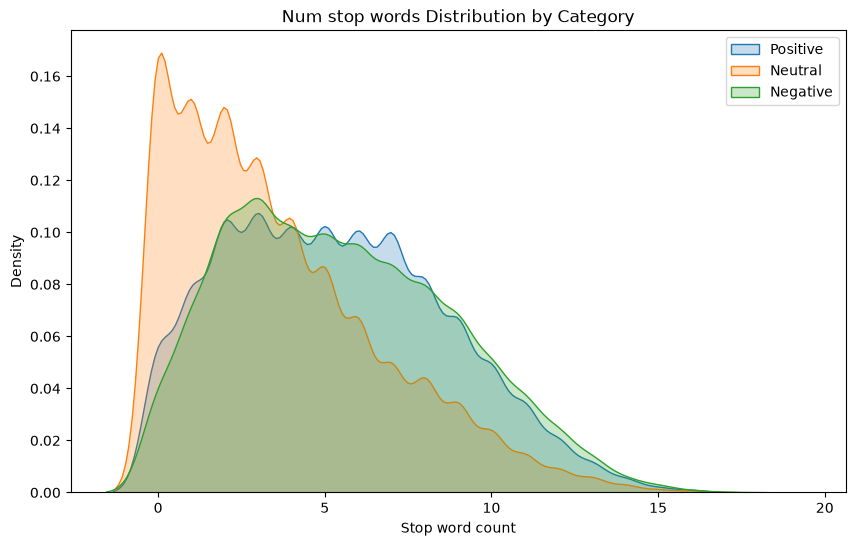

In [38]:
# Create the figure and axes
plt.figure(figsize=(10, 6))

# Plot KDE for category 1
sns.kdeplot(df[df['category'] == 1]['num_stop_words'], label='Positive', fill=True)

# Plot KDE for category 0
sns.kdeplot(df[df['category'] == 0]['num_stop_words'], label='Neutral', fill=True)

# Plot KDE for category -1
sns.kdeplot(df[df['category'] == -1]['num_stop_words'], label='Negative', fill=True)

# Add title and labels
plt.title('Num stop words Distribution by Category')
plt.xlabel('Stop word count')
plt.ylabel('Density')

# Add a legend
plt.legend()

# Show the plot
plt.show()

<Axes: xlabel='category', ylabel='num_stop_words'>

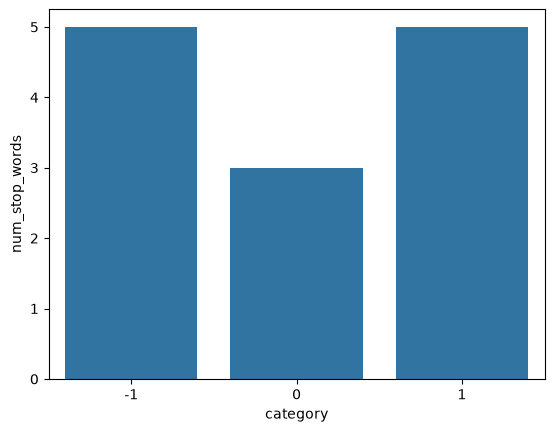

In [39]:
# median word counts among sentiments

sns.barplot(df,x='category',y='num_stop_words',estimator='median')

C:\Users\HAI\AppData\Local\Temp\ipykernel_20588\706517223.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_df, x='count', y='stop_word', palette='viridis')


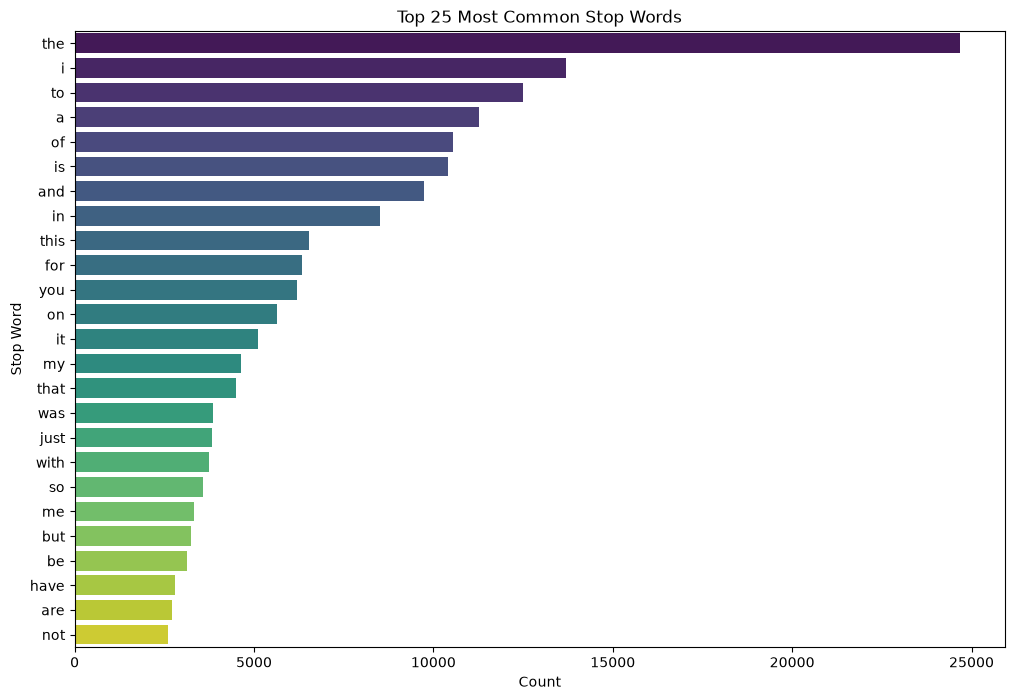

In [40]:
# Create a frequency distribution of stop words in the 'clean_comment' column
from collections import Counter

# Extract all stop words from the comments using the previously defined 'common_stopwords'
all_stop_words = [word for comment in df['clean_comment'] for word in comment.split() if word in stop_words]

# Count the most common stop words
most_common_stop_words = Counter(all_stop_words).most_common(25)

# Convert the most common stop words to a DataFrame for plotting
top_25_df = pd.DataFrame(most_common_stop_words, columns=['stop_word', 'count'])

# Create the barplot for the top 25 most common stop words
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_df, x='count', y='stop_word', palette='viridis')
plt.title('Top 25 Most Common Stop Words')
plt.xlabel('Count')
plt.ylabel('Stop Word')
plt.show()



In [41]:
df['num_chars'] = df['clean_comment'].apply(len)

df.head()

,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,clean_comment,source,is_retweet,sentiment_polarity,category,word_count,num_stop_words,num_chars
3,YoMo.Mdp,Any pronouns,Where the heck is the karma\nI'm going on my s...,2021-02-14 13:21:22+00:00,3,277,1341,False,2021-10-06 12:05:04+00:00,//blood on 1st slide i'm joining the squidgame...,Twitter Web App,False,-0.6486,-1,18,5,130
4,Laura Reactions,France,I talk and I make reactions videos about shows...,2018-12-19 20:38:28+00:00,330,152,2278,False,2021-10-06 12:05:00+00:00,"the two first games, players were killed by th...",Twitter Web App,False,-0.9169,-1,24,9,140
5,Peyman 🅚🅐🅘,United Kingdom,Official @KardiaChain $KAI Ambassador\nMarketi...,2018-01-27 12:07:31+00:00,546,318,6265,False,2021-10-06 12:04:54+00:00,$thg going to explode to 4b marketcap very soo...,Twitter for Android,False,0.0000,0,21,7,138
7,BarBiE Fábregas 🇿🇦,South Africa,Legal Administrator👩🏾‍💻|Soccer Fanatic⚽️ #Dail...,2011-03-28 18:56:28+00:00,1877,2057,33186,False,2021-10-06 12:04:26+00:00,please vote in my daily poll. thanks. 😊 do y...,Twitter for iPhone,False,0.8708,1,23,6,140
9,Kevin Franco,"Calgary, Canada",When it comes to describing myself in a one li...,2009-05-11 20:14:51+00:00,1027,278,20902,False,2021-10-06 12:04:10+00:00,i discovered english audio after 5 episodes of...,Twitter Web App,False,0.0000,0,21,7,140


In [42]:
df['num_chars'].describe()

count    54036.000000
mean       102.506126
std         35.621623
min         15.000000
25%         72.000000
50%        110.000000
75%        139.000000
max        322.000000
Name: num_chars, dtype: float64

In [43]:
from collections import Counter

# Combine all comments into one large string
all_text = ' '.join(df['clean_comment'])

# Count the frequency of each character
char_frequency = Counter(all_text)

# Convert the character frequency into a DataFrame for better display
char_frequency_df = pd.DataFrame(char_frequency.items(), columns=['character', 'frequency']).sort_values(by='frequency', ascending=False)



In [44]:
char_frequency_df['character'].values

array([' ', 'e', 't', ..., '🇾', '🍟', '¢'], dtype=object)

In [45]:
char_frequency_df.tail(50)

,character,frequency
1596,今,1
1581,⧫,1
629,❔,1
1566,୧,1
1568,୨,1
624,⚾,1
618,ə,1
1574,ŋ,1
1575,ɛ,1
1576,🌅,1


In [46]:
# Create a new column 'num_punctuation_chars' to count punctuation characters in each comment
df['num_punctuation_chars'] = df['clean_comment'].apply(
    lambda x: sum([1 for char in x if char in '.,!?;:"\'()[]{}-'])
)

df.sample(5)

,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,clean_comment,source,is_retweet,sentiment_polarity,category,word_count,num_stop_words,num_chars,num_punctuation_chars
59196,A. J. Black,South West / West Midlands,Author of books | Words @theQuietus @EscapistM...,2014-04-14 10:18:01+00:00,1567,990,40385,False,2021-10-21 08:30:17+00:00,a very interesting sneak peak through the tiny...,Twitter for iPhone,False,0.4576,1,21,8,140,3
43495,Petri von Hyvonen,This is the water and this is the well. Drink ...,Executive Producer of no-no-nonsense.,2009-06-05 06:24:46+00:00,81,559,2861,False,2021-10-15 14:38:34+00:00,should i watch the last episode of #squidgame ...,Twitter Web App,False,-0.3400,-1,11,5,61,1
51290,ghost izzy 👁👅👁,"Ohio, USA",if you DM me I’m just sending you my cashapp u...,2020-12-26 22:18:09+00:00,166,101,6331,False,2021-10-19 02:05:54+00:00,listen i love talking about #squidgame but are...,Twitter for iPhone,False,-0.4767,-1,24,13,129,0
16274,S.Antonio,"Accra, Ghana",Stay happy in your own world 😎❤,2015-09-15 13:10:32+00:00,1330,1841,6403,False,2021-10-06 19:48:15+00:00,when you watch movies like fast and furious th...,Twitter for Android,False,-0.2960,-1,22,8,140,4
43923,Jelle Simons,New York City,"Journalism, History, MA Military History - HQs...",2015-02-15 01:17:02+00:00,6110,5291,48490,False,2021-10-15 13:00:12+00:00,heineken is the emperor of advertisement. and ...,Twitter Web App,False,0.0000,0,13,5,107,4


In [47]:
df['num_punctuation_chars'].describe()

count    54036.000000
mean         3.392479
std          2.351464
min          0.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         66.000000
Name: num_punctuation_chars, dtype: float64

C:\Users\HAI\AppData\Local\Temp\ipykernel_20588\1638384091.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')


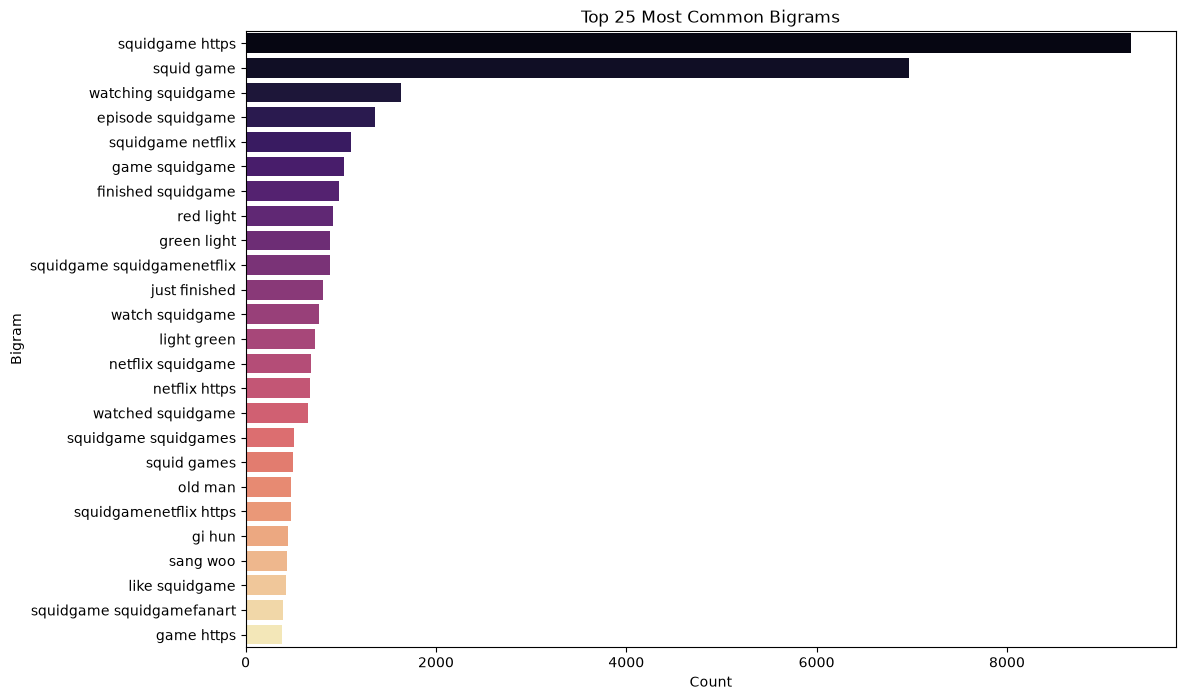

In [48]:
from sklearn.feature_extraction.text import CountVectorizer

# Create a function to extract the top 25 bigrams
def get_top_ngrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Get the top 25 bigrams
top_25_bigrams = get_top_ngrams(df['clean_comment'], 25)

# Convert the bigrams into a DataFrame for plotting
top_25_bigrams_df = pd.DataFrame(top_25_bigrams, columns=['bigram', 'count'])

# Plot the countplot for the top 25 bigrams
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')
plt.title('Top 25 Most Common Bigrams')
plt.xlabel('Count')
plt.ylabel('Bigram')
plt.show()


C:\Users\HAI\AppData\Local\Temp\ipykernel_20588\2492861520.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_trigrams_df, x='count', y='trigram', palette='coolwarm')


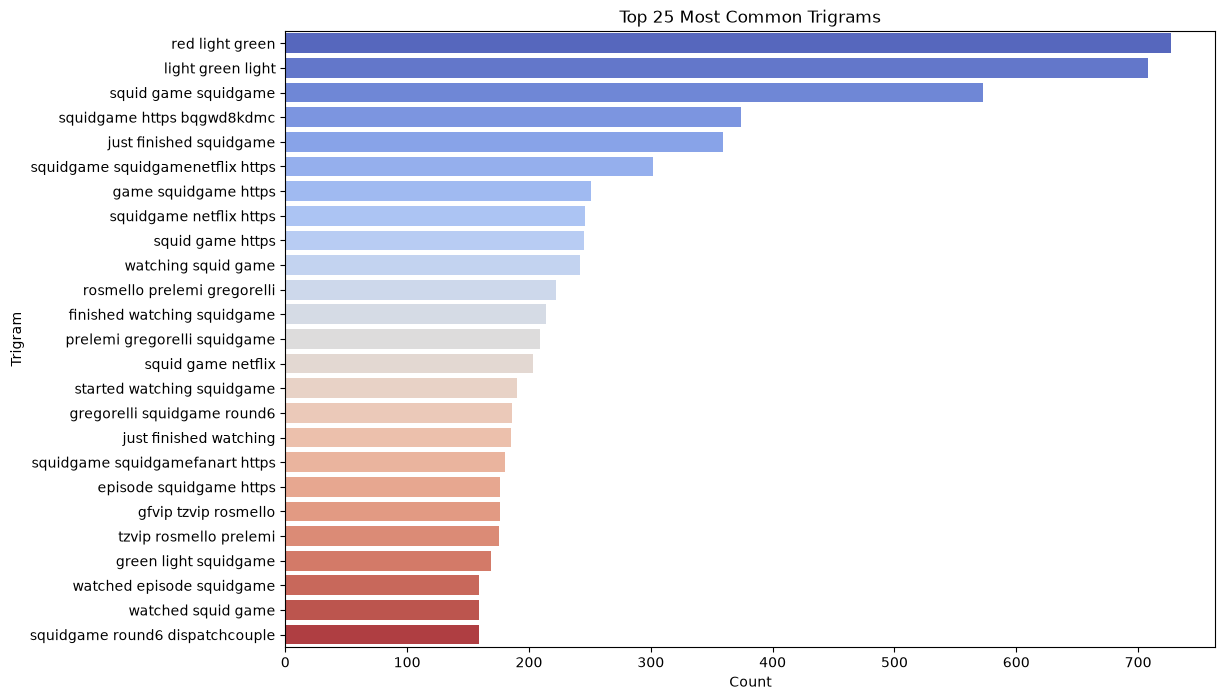

In [49]:
# Create a function to extract the top 25 trigrams
def get_top_trigrams(corpus, n=None):
    vec = CountVectorizer(ngram_range=(3, 3), stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Get the top 25 trigrams
top_25_trigrams = get_top_trigrams(df['clean_comment'], 25)

# Convert the trigrams into a DataFrame for plotting
top_25_trigrams_df = pd.DataFrame(top_25_trigrams, columns=['trigram', 'count'])

# Plot the countplot for the top 25 trigrams
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_trigrams_df, x='count', y='trigram', palette='coolwarm')
plt.title('Top 25 Most Common Trigrams')
plt.xlabel('Count')
plt.ylabel('Trigram')
plt.show()

In [50]:
# Remove non-English characters from the 'clean_comment' column
# Keeping only standard English letters, digits, and common punctuation
import re

df['clean_comment'] = df['clean_comment'].apply(lambda x: re.sub(r'[^A-Za-z0-9\s!?.,]', '', str(x)))


In [51]:
all_text = ' '.join(df['clean_comment'])

# Count the frequency of each character
char_frequency = Counter(all_text)

# Convert the character frequency into a DataFrame for better display
char_frequency_df = pd.DataFrame(char_frequency.items(), columns=['character', 'frequency']).sort_values(by='frequency', ascending=False)

char_frequency_df

,character,frequency
4,,812344
10,e,409949
8,t,398374
17,a,308110
9,i,305019
7,s,302929
2,o,290757
5,n,221501
14,h,201322
3,d,176725


In [52]:
df.head()

,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,clean_comment,source,is_retweet,sentiment_polarity,category,word_count,num_stop_words,num_chars,num_punctuation_chars
3,YoMo.Mdp,Any pronouns,Where the heck is the karma\nI'm going on my s...,2021-02-14 13:21:22+00:00,3,277,1341,False,2021-10-06 12:05:04+00:00,blood on 1st slide im joining the squidgame th...,Twitter Web App,False,-0.6486,-1,18,5,130,5
4,Laura Reactions,France,I talk and I make reactions videos about shows...,2018-12-19 20:38:28+00:00,330,152,2278,False,2021-10-06 12:05:00+00:00,"the two first games, players were killed by th...",Twitter Web App,False,-0.9169,-1,24,9,140,5
5,Peyman 🅚🅐🅘,United Kingdom,Official @KardiaChain $KAI Ambassador\nMarketi...,2018-01-27 12:07:31+00:00,546,318,6265,False,2021-10-06 12:04:54+00:00,thg going to explode to 4b marketcap very soon...,Twitter for Android,False,0.0000,0,21,7,138,4
7,BarBiE Fábregas 🇿🇦,South Africa,Legal Administrator👩🏾‍💻|Soccer Fanatic⚽️ #Dail...,2011-03-28 18:56:28+00:00,1877,2057,33186,False,2021-10-06 12:04:26+00:00,please vote in my daily poll. thanks. do yo...,Twitter for iPhone,False,0.8708,1,23,6,140,6
9,Kevin Franco,"Calgary, Canada",When it comes to describing myself in a one li...,2009-05-11 20:14:51+00:00,1027,278,20902,False,2021-10-06 12:04:10+00:00,i discovered english audio after 5 episodes of...,Twitter Web App,False,0.0000,0,21,7,140,4


In [53]:
from nltk.corpus import stopwords

# Defining stop words but keeping essential ones for sentiment analysis
stop_words = set(stopwords.words('english')) - {'not', 'but', 'however', 'no', 'yet'}

# Remove stop words from 'clean_comment' column, retaining essential ones
df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words])
)




In [54]:
df.head()

,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,clean_comment,source,is_retweet,sentiment_polarity,category,word_count,num_stop_words,num_chars,num_punctuation_chars
3,YoMo.Mdp,Any pronouns,Where the heck is the karma\nI'm going on my s...,2021-02-14 13:21:22+00:00,3,277,1341,False,2021-10-06 12:05:04+00:00,"blood 1st slide im joining squidgame thing, im...",Twitter Web App,False,-0.6486,-1,18,5,130,5
4,Laura Reactions,France,I talk and I make reactions videos about shows...,2018-12-19 20:38:28+00:00,330,152,2278,False,2021-10-06 12:05:00+00:00,"two first games, players killed mask guys bloo...",Twitter Web App,False,-0.9169,-1,24,9,140,5
5,Peyman 🅚🅐🅘,United Kingdom,Official @KardiaChain $KAI Ambassador\nMarketi...,2018-01-27 12:07:31+00:00,546,318,6265,False,2021-10-06 12:04:54+00:00,thg going explode 4b marketcap soon. world fir...,Twitter for Android,False,0.0000,0,21,7,138,4
7,BarBiE Fábregas 🇿🇦,South Africa,Legal Administrator👩🏾‍💻|Soccer Fanatic⚽️ #Dail...,2011-03-28 18:56:28+00:00,1877,2057,33186,False,2021-10-06 12:04:26+00:00,please vote daily poll. thanks. think donny va...,Twitter for iPhone,False,0.8708,1,23,6,140,6
9,Kevin Franco,"Calgary, Canada",When it comes to describing myself in a one li...,2009-05-11 20:14:51+00:00,1027,278,20902,False,2021-10-06 12:04:10+00:00,discovered english audio 5 episodes squid game...,Twitter Web App,False,0.0000,0,21,7,140,4


In [55]:
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

# Define the lemmatizer
lemmatizer = WordNetLemmatizer()

# Apply lemmatization to the 'clean_comment_no_stopwords' column
df['clean_comment'] = df['clean_comment'].apply(
    lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()])
)

df.head()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HAI\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,clean_comment,source,is_retweet,sentiment_polarity,category,word_count,num_stop_words,num_chars,num_punctuation_chars
3,YoMo.Mdp,Any pronouns,Where the heck is the karma\nI'm going on my s...,2021-02-14 13:21:22+00:00,3,277,1341,False,2021-10-06 12:05:04+00:00,"blood 1st slide im joining squidgame thing, im...",Twitter Web App,False,-0.6486,-1,18,5,130,5
4,Laura Reactions,France,I talk and I make reactions videos about shows...,2018-12-19 20:38:28+00:00,330,152,2278,False,2021-10-06 12:05:00+00:00,"two first games, player killed mask guy bloody...",Twitter Web App,False,-0.9169,-1,24,9,140,5
5,Peyman 🅚🅐🅘,United Kingdom,Official @KardiaChain $KAI Ambassador\nMarketi...,2018-01-27 12:07:31+00:00,546,318,6265,False,2021-10-06 12:04:54+00:00,thg going explode 4b marketcap soon. world fir...,Twitter for Android,False,0.0000,0,21,7,138,4
7,BarBiE Fábregas 🇿🇦,South Africa,Legal Administrator👩🏾‍💻|Soccer Fanatic⚽️ #Dail...,2011-03-28 18:56:28+00:00,1877,2057,33186,False,2021-10-06 12:04:26+00:00,please vote daily poll. thanks. think donny va...,Twitter for iPhone,False,0.8708,1,23,6,140,6
9,Kevin Franco,"Calgary, Canada",When it comes to describing myself in a one li...,2009-05-11 20:14:51+00:00,1027,278,20902,False,2021-10-06 12:04:10+00:00,discovered english audio 5 episode squid game ...,Twitter Web App,False,0.0000,0,21,7,140,4


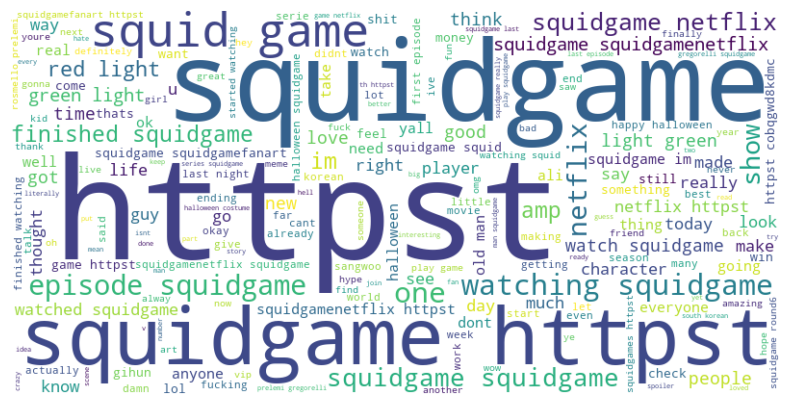

In [56]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

plot_word_cloud(df['clean_comment'])

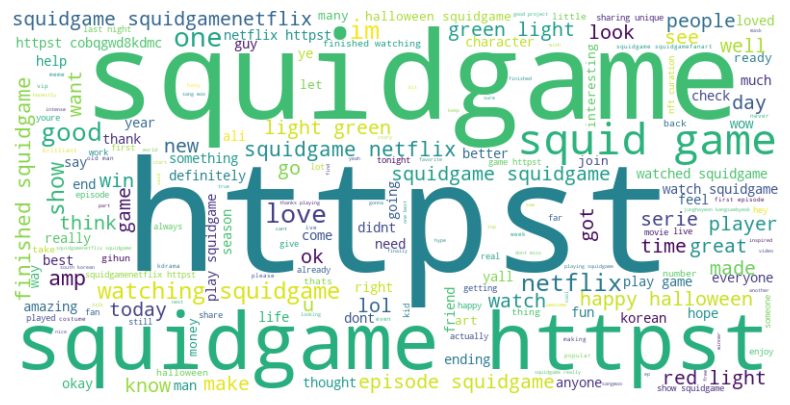

In [57]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

plot_word_cloud(df[df['category'] == 1]['clean_comment'])

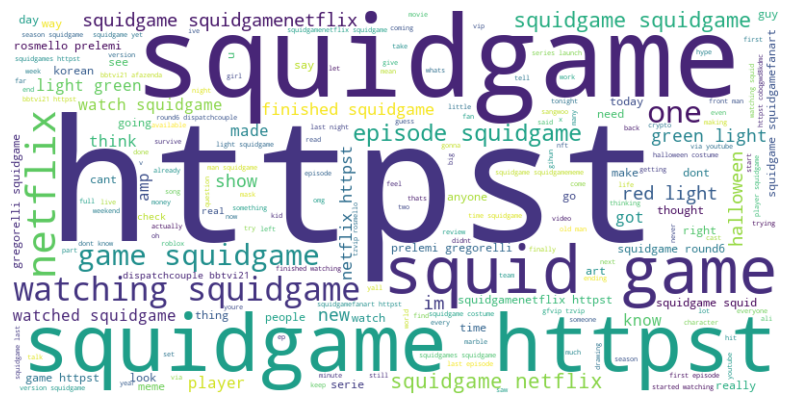

In [58]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

plot_word_cloud(df[df['category'] == 0]['clean_comment'])

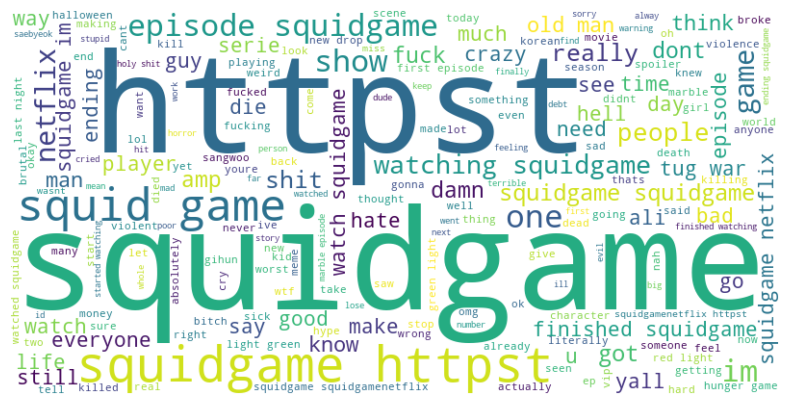

In [59]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

plot_word_cloud(df[df['category'] == -1]['clean_comment'])

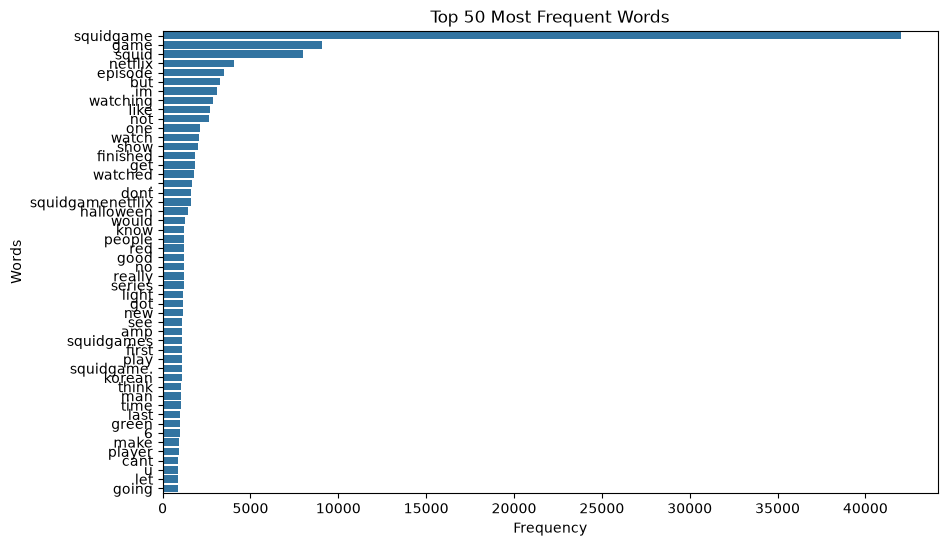

In [60]:
def plot_top_n_words(df, n=20):
    """Plot the top N most frequent words in the dataset."""
    # Flatten all words in the content column
    words = ' '.join(df['clean_comment']).split()

    # Get the top N most common words
    counter = Counter(words)
    most_common_words = counter.most_common(n)

    # Split the words and their counts for plotting
    words, counts = zip(*most_common_words)

    # Plot the top N words
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(words))
    plt.title(f'Top {n} Most Frequent Words')
    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.show()

# Example usage
plot_top_n_words(df, n=50)


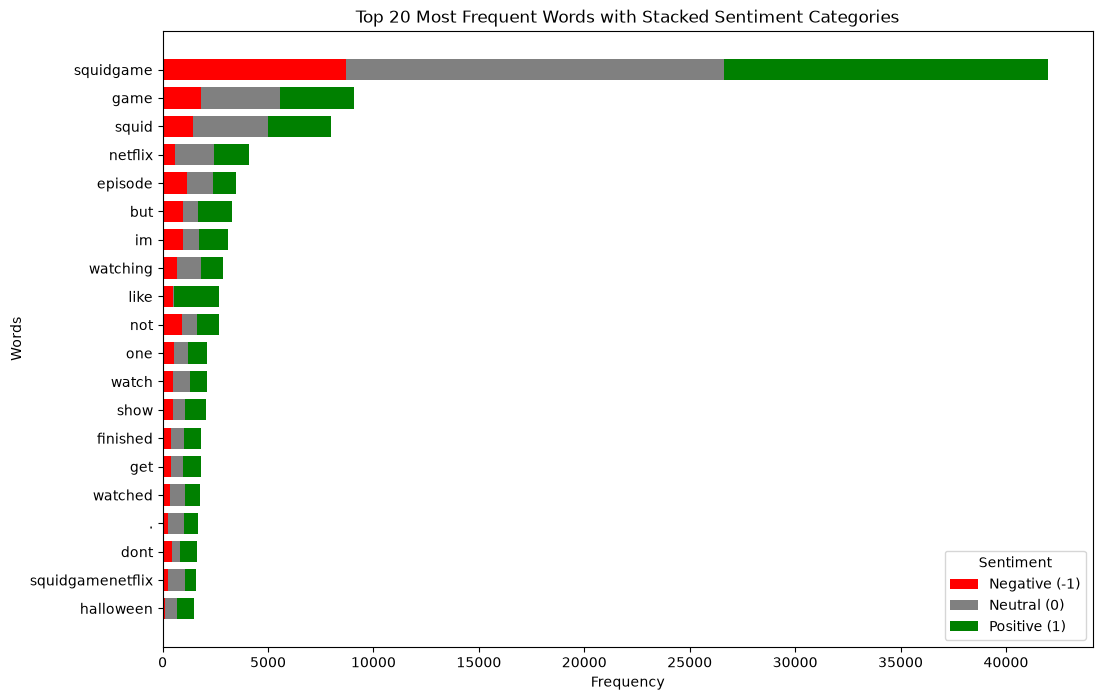

In [61]:
def plot_top_n_words_by_category(df, n=20, start=0):
    """Plot the top N most frequent words in the dataset with stacked hue based on sentiment category."""
    # Flatten all words in the content column and count their occurrences by category
    word_category_counts = {}

    for idx, row in df.iterrows():
        words = row['clean_comment'].split()
        category = row['category']  # Assuming 'category' column exists for -1, 0, 1 labels

        for word in words:
            if word not in word_category_counts:
                word_category_counts[word] = { -1: 0, 0: 0, 1: 0 }  # Initialize counts for each sentiment category

            # Increment the count for the corresponding sentiment category
            word_category_counts[word][category] += 1

    # Get total counts across all categories for each word
    total_word_counts = {word: sum(counts.values()) for word, counts in word_category_counts.items()}

    # Get the top N most frequent words across all categories
    most_common_words = sorted(total_word_counts.items(), key=lambda x: x[1], reverse=True)[start:start+n]
    top_words = [word for word, _ in most_common_words]

    # Prepare data for plotting
    word_labels = top_words
    negative_counts = [word_category_counts[word][-1] for word in top_words]
    neutral_counts = [word_category_counts[word][0] for word in top_words]
    positive_counts = [word_category_counts[word][1] for word in top_words]

    # Plot the stacked bar chart
    plt.figure(figsize=(12, 8))
    bar_width = 0.75

    # Plot negative, neutral, and positive counts in a stacked manner
    plt.barh(word_labels, negative_counts, color='red', label='Negative (-1)', height=bar_width)
    plt.barh(word_labels, neutral_counts, left=negative_counts, color='gray', label='Neutral (0)', height=bar_width)
    plt.barh(word_labels, positive_counts, left=[i+j for i,j in zip(negative_counts, neutral_counts)], color='green', label='Positive (1)', height=bar_width)

    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.title(f'Top {n} Most Frequent Words with Stacked Sentiment Categories')
    plt.legend(title='Sentiment', loc='lower right')
    plt.gca().invert_yaxis()  # Invert y-axis to show the highest frequency at the top
    plt.show()



plot_top_n_words_by_category(df, n=20)
